In [ ]:
import numpy as np
import scipy.io as sio
import pandas as pd
import urllib.request
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import subprocess
import shlex

In [ ]:
# ==============================================================================
# Data Generation & Signal Conditioning
# ==============================================================================
def extract_rar_files(rar_files, output_dir):

    try:
        print("Installing unrar...")
        subprocess.run(shlex.split('apt-get install -y unrar'), check=True, capture_output=True, text=True)
        print("unrar installed successfully.")
    except subprocess.CalledProcessError as e:
        print(f"Failed to install unrar: {e.stderr}")
        return

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for rar_file in rar_files:
        if os.path.exists(rar_file):
            print(f"Extracting {rar_file}...")
            try:
                subprocess.run(['unrar', 'x', '-o+', rar_file, output_dir], check=True, capture_output=True, text=True)
                print(f"Extraction of {rar_file} complete.")
            except subprocess.CalledProcessError as e:
                print(f"Failed to extract {rar_file}: {e.stderr}")
        else:
            print(f"File not found: {rar_file}")

def download_and_extract_from_gdrive(file_ids, file_names, output_dir):

    try:
        print("Installing gdown...")
        subprocess.run(shlex.split('pip install gdown'), check=True, capture_output=True, text=True)
        print("gdown installed successfully.")
    except subprocess.CalledProcessError as e:
        print(f"Failed to install gdown: {e.stderr}")
        return

    for file_name in file_names:
        file_id = file_ids.get(file_name)
        if file_id:
            print(f"Downloading {file_name} from Google Drive...")
            try:
                command = f"gdown --id {file_id} -O {file_name}"
                subprocess.run(shlex.split(command), check=True)
                print(f"Download of {file_name} complete.")
            except subprocess.CalledProcessError as e:
                print(f"Failed to download {file_name}: {e}")
        else:
            print(f"Error: No Google Drive ID found for file '{file_name}'.")

    extract_rar_files(file_names, output_dir)

def load_data(data_path, label):

    data = sio.loadmat(data_path)
    vibration_data = None
    for key in data.keys():
        if 'DE_time' in key:
            vibration_data = data[key]
            break
    if vibration_data is None:
        raise KeyError(f"Could not find a valid vibration data key in {data_path}. Check the .mat file keys.")
    return vibration_data.flatten(), label

def get_cwru_dataset_local(data_dir):
    """
    Loads .mat files from the specified local directory and assigns labels based on filename.
    """
    print("Loading data from local directory...")
    X, y = [], []

    file_label_map = {
        '118_0.mat': 'BallFault', '119_1.mat': 'BallFault', '120_2.mat': 'BallFault', '121_3.mat': 'BallFault',
        '185_0.mat': 'BallFault', '186_1.mat': 'BallFault', '187_2.mat': 'BallFault', '188_3.mat': 'BallFault',
        '222_0.mat': 'BallFault', '223_1.mat': 'BallFault', '224_2.mat': 'BallFault', '225_3.mat': 'BallFault',
        '105_0.mat': 'InnerRace', '106_1.mat': 'InnerRace', '107_2.mat': 'InnerRace', '108_3.mat': 'InnerRace',
        '169_0.mat': 'InnerRace', '170_1.mat': 'InnerRace', '171_2.mat': 'InnerRace', '172_3.mat': 'InnerRace',
        '209_0.mat': 'InnerRace', '210_1.mat': 'InnerRace', '211_2.mat': 'InnerRace', '212_3.mat': 'InnerRace',
        '144_0.mat': 'OuterRace', '145_1.mat': 'OuterRace', '146_2.mat': 'OuterRace', '147_3.mat': 'OuterRace',
        '197@6_0.mat': 'OuterRace', '198@6_1.mat': 'OuterRace', '199@6_2.mat': 'OuterRace', '200@6_3.mat': 'OuterRace',
        '246_0.mat': 'OuterRace', '247_1.mat': 'OuterRace', '248_2.mat': 'OuterRace', '249_3.mat': 'OuterRace'
    }

    for root, dirs, files in os.walk(data_dir):
        for file in files:
            filepath = os.path.join(root, file)

            if os.path.basename(root) == 'Fault_data' and file in file_label_map:
                current_label = file_label_map[file]
                try:
                    signal, _ = load_data(filepath, current_label)
                    X.append(signal)
                    y.append(current_label)
                    print(f"Loaded {filepath} with label '{current_label}'")
                except KeyError as e:
                    print(f"Skipping {filepath} due to an error: {e}")

            elif os.path.basename(root) == 'Normal' and file.endswith('.mat'):
                 try:
                    signal, _ = load_data(filepath, 'Normal')
                    X.append(signal)
                    y.append('Normal')
                    print(f"Loaded {filepath} with label 'Normal'")
                 except KeyError as e:
                    print(f"Skipping {filepath} due to an error: {e}")

    if not X:
        print(f"Warning: No .mat files found in the '{data_dir}' directory with the expected structure.")

    return X, y

In [ ]:
# ==============================================================================
# Feature Extraction
# ==============================================================================

def extract_features(signal, segment_length=2048):

    n_segments = len(signal) // segment_length
    features_list = []

    for i in range(n_segments):
        segment = signal[i*segment_length : (i+1)*segment_length]

        if len(segment) == 0:
            continue

        # Calculate time-domain features
        feature_dict = {
            'rms': np.sqrt(np.mean(segment**2)),
            'std_dev': np.std(segment),
            'max_val': np.max(np.abs(segment)),
            'min_val': np.min(np.abs(segment)),
            'kurtosis': pd.Series(segment).kurt(),
            'skewness': pd.Series(segment).skew(),
            'crest_factor': np.max(np.abs(segment)) / np.sqrt(np.mean(segment**2)) if np.sqrt(np.mean(segment**2)) != 0 else 0,
            'form_factor': np.sqrt(np.mean(segment**2)) / np.mean(np.abs(segment)) if np.mean(np.abs(segment)) != 0 else 0,
        }
        features_list.append(feature_dict)

    return pd.DataFrame(features_list)


In [ ]:
# ==============================================================================
# Model Development
# ==============================================================================
pop_size = 25
max_iter = 15
c1 = 2.0
c2 = 2.0
w = 0.9
kfolds = 10

def pso_svm_optimizer(X_train, y_train):

    class Particle:
        def __init__(self, bounds_C, bounds_gamma):
            self.position = [np.random.uniform(bounds_C[0], bounds_C[1]),
                             np.random.uniform(bounds_gamma[0], bounds_gamma[1])]
            self.velocity = [np.random.uniform(-1, 1), np.random.uniform(-1, 1)]
            self.best_position = self.position[:]
            self.best_fitness = -1.0

    bounds_C = [1e-3, 1e3]
    bounds_gamma = [1e-3, 1e3]
    swarm = [Particle(bounds_C, bounds_gamma) for _ in range(pop_size)]
    global_best_position = swarm[0].position[:]
    global_best_fitness = -1.0

    for i in range(max_iter):
        print(f"\n--- Iteration {i+1}/{max_iter} ---")
        for particle in swarm:
            C, gamma = particle.position
            skf = StratifiedKFold(n_splits=kfolds, shuffle=True, random_state=42)
            cv_scores = []

            y_train_encoded = pd.factorize(y_train)[0]

            if len(np.unique(y_train_encoded)) < kfolds:
                n_splits = len(np.unique(y_train_encoded))
            else:
                n_splits = kfolds
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

            for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_encoded)):
                X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
                y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

                try:
                    svm = SVC(C=C, gamma=gamma, kernel='rbf', random_state=42)
                    svm.fit(X_train_fold, y_train_fold)
                    y_pred = svm.predict(X_val_fold)
                    accuracy = accuracy_score(y_val_fold, y_pred)
                    cv_scores.append(accuracy)
                except Exception as e:
                    cv_scores.append(0)

            current_fitness = np.mean(cv_scores)

            if current_fitness > particle.best_fitness:
                particle.best_fitness = current_fitness
                particle.best_position = particle.position[:]

            if current_fitness > global_best_fitness:
                global_best_fitness = current_fitness
                global_best_position = particle.position[:]

            r1, r2 = np.random.rand(2)
            for j in range(2):
                particle.velocity[j] = (w * particle.velocity[j] +
                                        c1 * r1 * (particle.best_position[j] - particle.position[j]) +
                                        c2 * r2 * (global_best_position[j] - particle.position[j]))

                particle.position[j] += particle.velocity[j]

                particle.position[j] = max(particle.position[j], bounds_C[0] if j==0 else bounds_gamma[0])
                particle.position[j] = min(particle.position[j], bounds_C[1] if j==0 else bounds_gamma[1])

        print(f"Iteration {i+1}/{max_iter}: Global best accuracy = {global_best_fitness:.4f}, C={global_best_position[0]:.4f}, gamma={global_best_position[1]:.4f}")

    print("PSO optimization complete.")
    return global_best_position

In [ ]:
# ==============================================================================
# Main execution
# ==============================================================================
if __name__ == "__main__":
    gdrive_file_ids = {
        'Normal_data.rar': '1KYpNxiLd-oQjl4Q_OyvEMTzCElDmaEjT',
        'Fault_data.rar': '18T1juYLGT5RaZREcZlIdB3RelDB2LsDE'
    }

    rar_files_to_download = ['Normal_data.rar', 'Fault_data.rar']
    data_output_directory = 'CWRU_data'

    download_and_extract_from_gdrive(gdrive_file_ids, rar_files_to_download, data_output_directory)

    # Load the local CWRU dataset
    raw_signals, labels = get_cwru_dataset_local(data_output_directory)

    if not raw_signals:
        print("No data was loaded. Exiting.")
    else:
        feature_dfs = [extract_features(signal, segment_length=2048) for signal in raw_signals]

        for df, label in zip(feature_dfs, labels):
            df['label'] = label

        full_dataset = pd.concat(feature_dfs, ignore_index=True)

        print("\n--- Dataset Overview ---")
        print(f"Total number of feature sets: {len(full_dataset)}")
        print("Count of each class label:")
        print(full_dataset['label'].value_counts())

        X = full_dataset.drop('label', axis=1)
        y = full_dataset['label']

        # Data preprocessing
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y.values, test_size=0.3, random_state=42, stratify=y)

        # Run the PSO optimizer to find the best C and gamma
        optimal_C, optimal_gamma = pso_svm_optimizer(X_train, y_train)


Installing gdown...
gdown installed successfully.
Download of Normal_data.rar complete.
Download of Fault_data.rar complete.
Installing unrar...
unrar installed successfully.
Extracting Normal_data.rar...
Extraction of Normal_data.rar complete.
Extracting Fault_data.rar...
Extraction of Fault_data.rar complete.
Loading data from local directory...
Loaded CWRU_data/Normal/100.mat with label 'Normal'
Loaded CWRU_data/Normal/99.mat with label 'Normal'
Loaded CWRU_data/Normal/98.mat with label 'Normal'
Loaded CWRU_data/Normal/97.mat with label 'Normal'
Loaded CWRU_data/Fault_data/186_1.mat with label 'BallFault'
Loaded CWRU_data/Fault_data/225_3.mat with label 'BallFault'
Loaded CWRU_data/Fault_data/120_2.mat with label 'BallFault'
Loaded CWRU_data/Fault_data/223_1.mat with label 'BallFault'
Loaded CWRU_data/Fault_data/199@6_2.mat with label 'OuterRace'
Loaded CWRU_data/Fault_data/187_2.mat with label 'BallFault'
Loaded CWRU_data/Fault_data/200@6_3.mat with label 'OuterRace'
Loaded CWRU_da


Evaluating final model with 5-fold cross-validation...

--- Cross-Validation Results ---
Average Accuracy: 0.9628 (+/- 0.0050)
Average Precision: 0.9629 (+/- 0.0051)
Average Recall: 0.9628 (+/- 0.0050)
Average F1-Score: 0.9627 (+/- 0.0050)


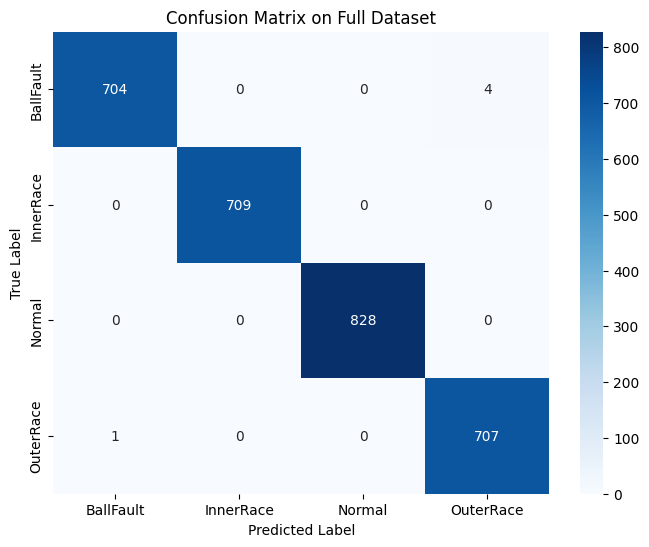

In [ ]:
# ==============================================================================
# Model Prediction and Evaluation
# ==============================================================================
def evaluate_model_with_kfold(model, X, y, kfolds=5):

    print(f"\nEvaluating final model with {kfolds}-fold cross-validation...")
    skf = StratifiedKFold(n_splits=kfolds, shuffle=True, random_state=42)

    accuracies, precisions, recalls, f1_scores = [], [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_test_fold)

        accuracies.append(accuracy_score(y_test_fold, y_pred_fold))
        precisions.append(precision_score(y_test_fold, y_pred_fold, average='weighted'))
        recalls.append(recall_score(y_test_fold, y_pred_fold, average='weighted'))
        f1_scores.append(f1_score(y_test_fold, y_pred_fold, average='weighted'))

    print("\n--- Cross-Validation Results ---")
    print(f"Average Accuracy: {np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")
    print(f"Average Precision: {np.mean(precisions):.4f} (+/- {np.std(precisions):.4f})")
    print(f"Average Recall: {np.mean(recalls):.4f} (+/- {np.std(recalls):.4f})")
    print(f"Average F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

    return accuracies, precisions, recalls, f1_scores

if __name__ == "__main__":

    final_svm = SVC(C=optimal_C, gamma=optimal_gamma, kernel='rbf', random_state=42)
    evaluate_model_with_kfold(final_svm, X_scaled, y)

    final_svm.fit(X_scaled, y)

    y_pred = final_svm.predict(X_scaled)
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title('Confusion Matrix on Full Dataset')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()